# Notebook 02: Modeling & Evaluation


## **Intelligent Loan Pricing & Risk Management for Australian Banks**
### **Author: Pranamya Rajbhandari**

## **1. Import Python Libraries**

In [1]:
import os
os.chdir('..') 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, roc_curve, auc)
from imblearn.over_sampling import SMOTE
import pickle
import warnings
import os

warnings.filterwarnings('ignore')

## **2. Load Engineered Data**

In [2]:
df_model = pd.read_csv('data\\raw\\data_engineered_for_modeling.csv')

print("="*70)
print("DATA LOADED FOR MODELING")
print("="*70)
print(f"Shape: {df_model.shape}")
print(f"Columns: {df_model.columns.tolist()[:10]}... (showing first 10)")
print(f"\nTarget variable distribution:")
print(df_model['loan_approved'].value_counts())
print(f"Approval rate: {(df_model['loan_approved'] == 1).sum() / len(df_model) * 100:.1f}%")

df_model = df_model.drop('application_date', axis=1) #drop application_date as it is not needed for modeling



DATA LOADED FOR MODELING
Shape: (2000, 80)
Columns: ['application_date', 'age', 'annual_income', 'credit_score', 'employment_status', 'education_level', 'experience', 'loan_amount', 'loan_duration', 'marital_status']... (showing first 10)

Target variable distribution:
loan_approved
1    1254
0     746
Name: count, dtype: int64
Approval rate: 62.7%


## **3. Prepare Data for Modeling**

In [3]:
drop_cols = [
    'loan_approved'
]

X = df_model.drop(drop_cols, axis=1)
y = df_model['loan_approved']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

folder_path = 'data\\processed'
os.makedirs(folder_path, exist_ok=True)
X_test_unscaled = X_test.copy()  # Keep original
X_test_unscaled.to_csv(os.path.join(folder_path, 'X_test_unscaled.csv'), index=False)


scaler = StandardScaler()
scaler.fit(X)
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train approval rate: {(y_train == 1).sum() / len(y_train) * 100:.1f}%")
print(f"Test approval rate: {(y_test == 1).sum() / len(y_test) * 100:.1f}%")



Features shape: (2000, 78)
Target shape: (2000,)

Train set: (1600, 78)
Test set: (400, 78)
Train approval rate: 62.7%
Test approval rate: 62.7%


## **4. Handle Class Imbalance With SMOTE**

In [4]:
# Ensure target is discrete (0 and 1)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Balanced training set: {X_train_balanced.shape}")
print(f"Class distribution:")
print(pd.Series(y_train_balanced).value_counts())
print(f"Balanced approval rate: {(y_train_balanced == 1).sum() / len(y_train_balanced) * 100:.1f}%")



After SMOTE:
Balanced training set: (2006, 78)
Class distribution:
loan_approved
1    1003
0    1003
Name: count, dtype: int64
Balanced approval rate: 50.0%


## **5. Train Baseline Models**

In [5]:

print("TRAINING MODELS")


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth = 12, min_samples_leaf = 5, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    predictions[name] = y_pred
    probabilities[name] = y_pred_proba
    
    print(f"  - Fitted on {X_train_balanced.shape[0]} samples")

TRAINING MODELS

Training Logistic Regression...
  - Fitted on 2006 samples

Training Random Forest...
  - Fitted on 2006 samples

Training Gradient Boosting...
  - Fitted on 2006 samples


## **6. Evaluate Models**

In [6]:
print("MODEL EVALUATION")
results = {}

for name, model in trained_models.items():
    y_pred = predictions[name]
    y_pred_proba = probabilities[name]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': roc_auc
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {roc_auc:.4f}")

results_df = pd.DataFrame(results).T
print("\n" + "="*70)
print("MODEL COMPARISON")
print(results_df)

MODEL EVALUATION

Logistic Regression:
  Accuracy:  0.7850
  Precision: 0.8210
  Recall:    0.8406
  F1-Score:  0.8307
  AUC-ROC:   0.8340

Random Forest:
  Accuracy:  0.8050
  Precision: 0.8289
  Recall:    0.8685
  F1-Score:  0.8482
  AUC-ROC:   0.8408

Gradient Boosting:
  Accuracy:  0.7850
  Precision: 0.8137
  Recall:    0.8526
  F1-Score:  0.8327
  AUC-ROC:   0.8286

MODEL COMPARISON
                     Accuracy  Precision    Recall  F1-Score   AUC-ROC
Logistic Regression     0.785   0.821012  0.840637  0.830709  0.833980
Random Forest           0.805   0.828897  0.868526  0.848249  0.840798
Gradient Boosting       0.785   0.813688  0.852590  0.832685  0.828578


## **7. Visualize Model Performance**

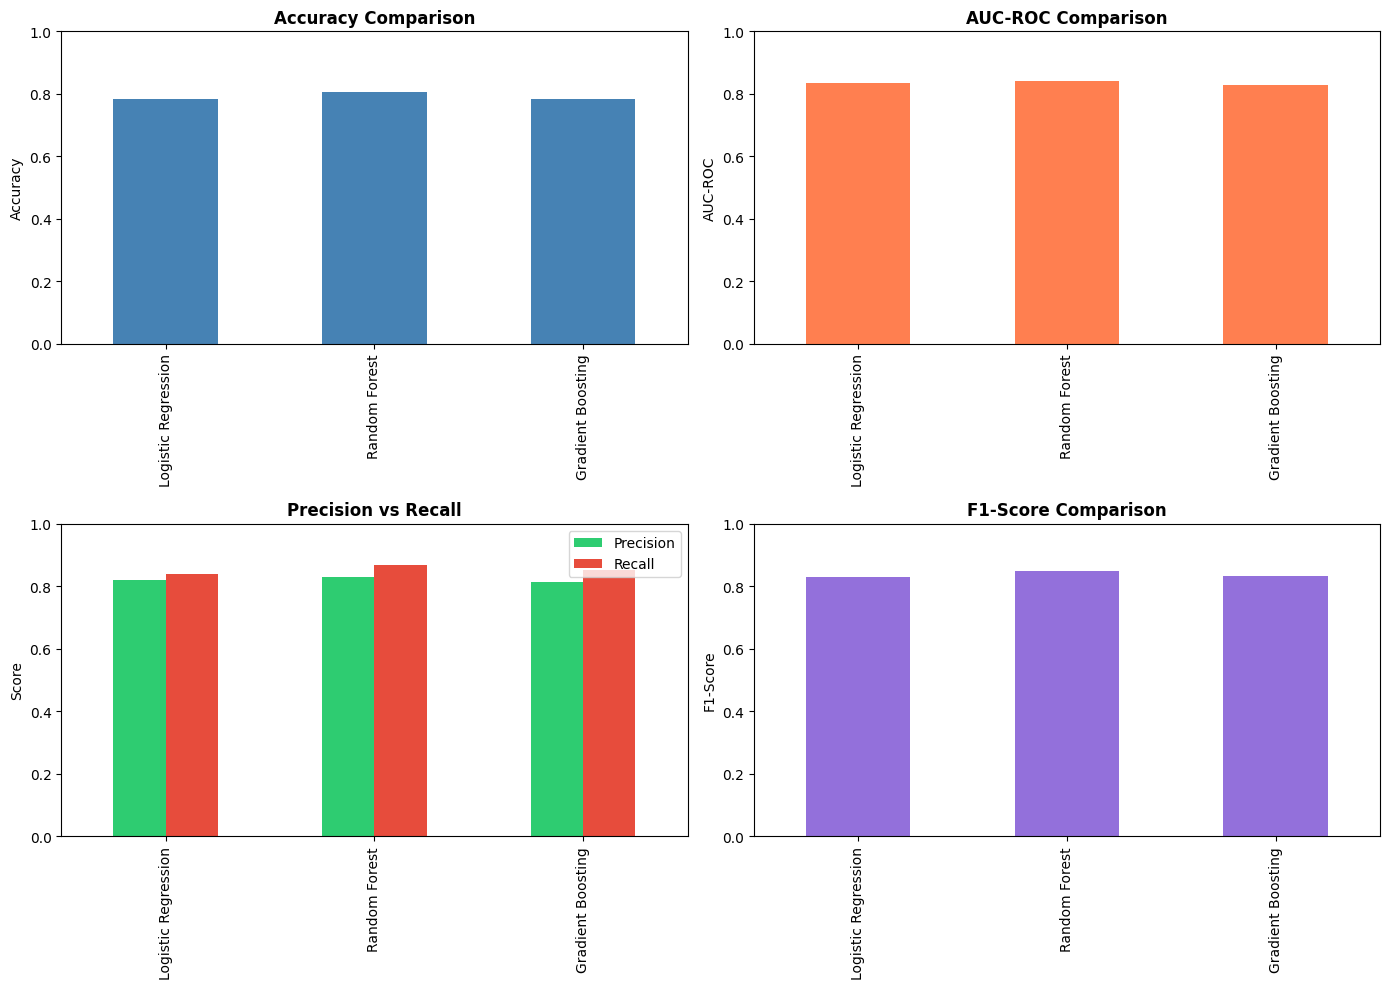

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

results_df['Accuracy'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Accuracy Comparison', fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim([0, 1])

results_df['AUC-ROC'].plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('AUC-ROC Comparison', fontweight='bold')
axes[0, 1].set_ylabel('AUC-ROC')
axes[0, 1].set_ylim([0, 1])

results_df[['Precision', 'Recall']].plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Precision vs Recall', fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim([0, 1])

results_df['F1-Score'].plot(kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('F1-Score Comparison', fontweight='bold')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()


## **8. ROC Curves**

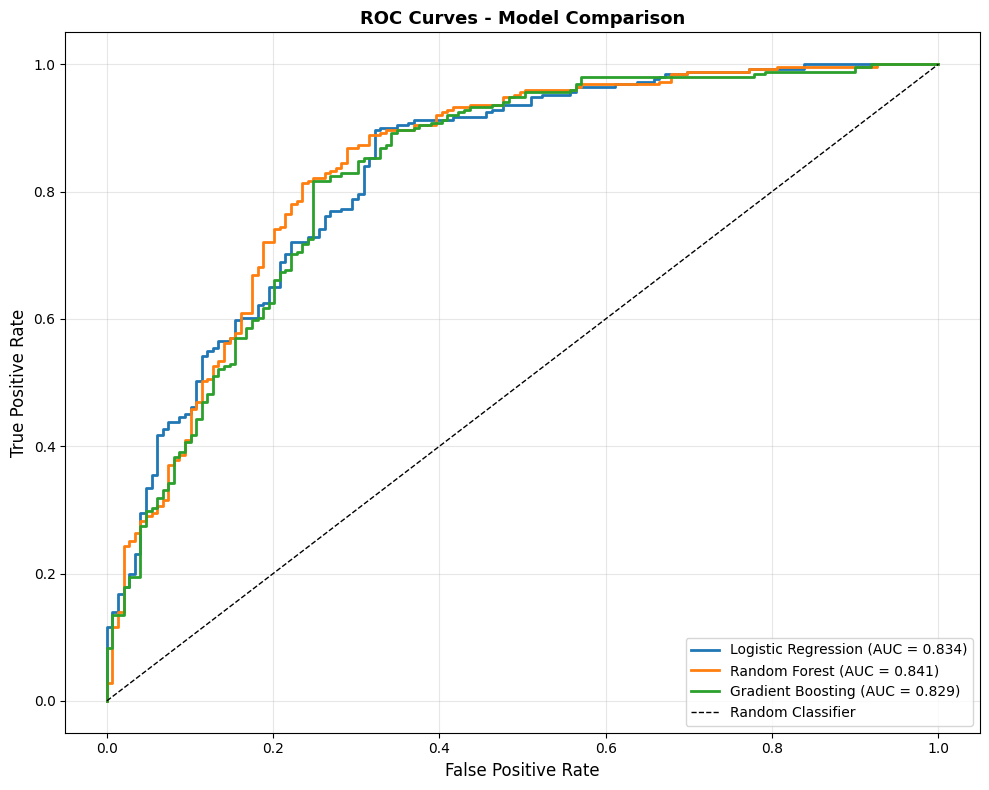

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in trained_models.items():
    y_pred_proba = probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **9. Confusion Matrices**


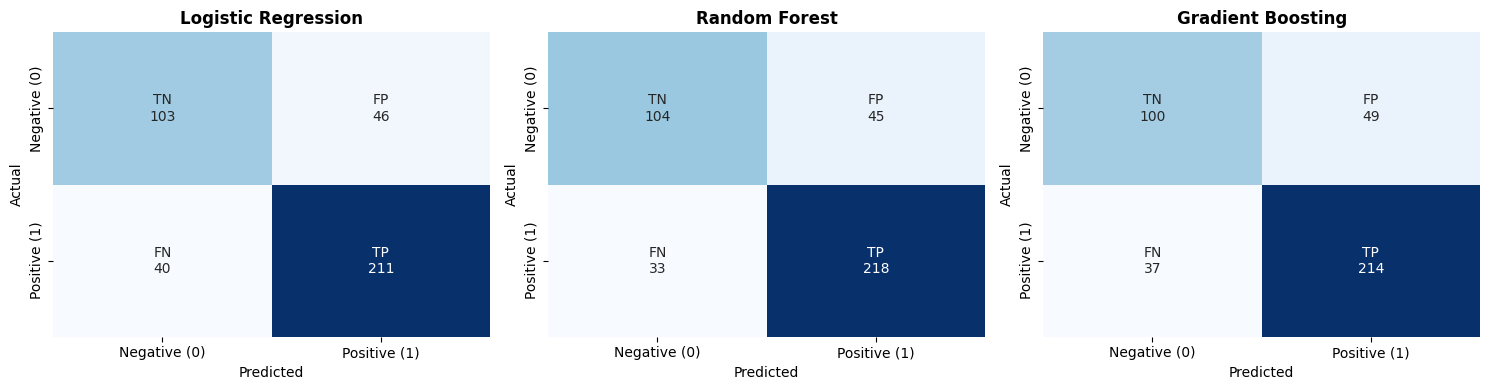

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Axis tick labels to replace 0 and 1
labels = ['Negative (0)', 'Positive (1)']

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    
    # Extract binary classification counts (scikit-learn order: TN, FP, FN, TP)
    tn, fp, fn, tp = cm.ravel()
    
    # Create custom 2x2 string annotations for heatmap cells
    annot_labels = np.array([
        [f"TN\n{tn}", f"FP\n{fp}"],
        [f"FN\n{fn}", f"TP\n{tp}"]
    ])
    
    sns.heatmap(
        cm, 
        annot=annot_labels, 
        fmt='',                   # Required when passing custom text matrices
        cmap='Blues', 
        ax=axes[idx], 
        cbar=False,
        xticklabels=labels,       # Replaces 0 and 1 on X-axis
        yticklabels=labels        # Replaces 0 and 1 on Y-axis
    )
    
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## **10. Select Best Model**


In [10]:
best_model_name = results_df['AUC-ROC'].idxmax()
best_model = trained_models[best_model_name]

print("BEST MODEL SELECTED\n")
print(f"Model: {best_model_name}")
print(f"AUC-ROC: {results_df.loc[best_model_name, 'AUC-ROC']:.4f}")
print(f"Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}\n")

# Cross-Validation

print("\nCROSS-VALIDATION (5-Fold)\n")

cv_scores = cross_val_score(best_model, X_train_balanced, y_train_balanced, 
                             cv=5, scoring='roc_auc')

print(f"CV AUC-ROC scores: {cv_scores}")
print(f"Mean CV AUC-ROC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

BEST MODEL SELECTED

Model: Random Forest
AUC-ROC: 0.8408
Accuracy: 0.8050


CROSS-VALIDATION (5-Fold)

CV AUC-ROC scores: [0.84940967 0.84763682 0.84191542 0.90820896 0.90920398]
Mean CV AUC-ROC: 0.8713 (+/- 0.0307)


## **11. Feature Importance**

TOP 20 FEATURE IMPORTANCES
                         feature  importance
66          loan_to_income_ratio    0.105066
32    total_debt_to_income_ratio    0.094850
33                    risk_score    0.071119
30          monthly_loan_payment    0.049749
6                    loan_amount    0.046175
42         savings_to_loan_ratio    0.040155
65             large_loan_amount    0.033238
7                  loan_duration    0.032463
28            base_interest_rate    0.030988
57               monthly_surplus    0.023129
1                  annual_income    0.022555
31          debt_to_income_ratio    0.021054
29                 interest_rate    0.020834
24                monthly_income    0.020128
16                  loan_purpose    0.018461
2                   credit_score    0.016386
22                  total_assets    0.016273
21      checking_account_balance    0.016216
20       savings_account_balance    0.016208
12  credit_card_utilisation_rate    0.015936
feature       78
importance 

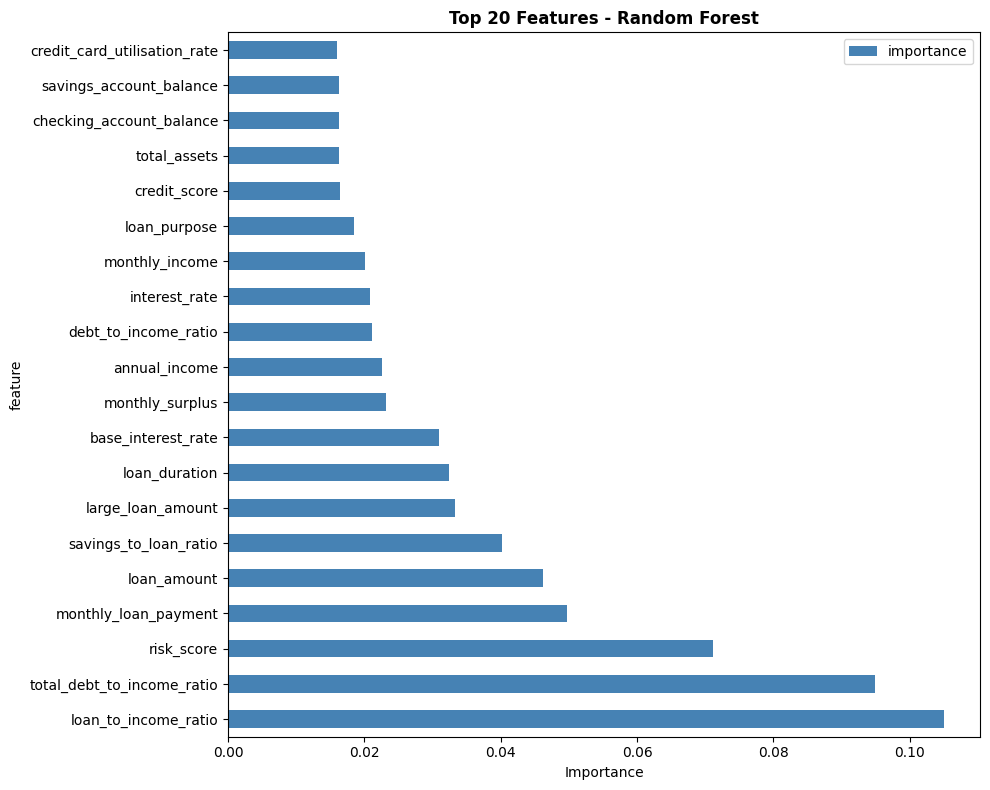

In [11]:
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("TOP 20 FEATURE IMPORTANCES")
    print(feature_importance.head(20))
    
    print(feature_importance.count())
    
    fig, ax = plt.subplots(figsize=(10, 8))
    feature_importance.head(20).plot(x='feature', y='importance', kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 20 Features - {best_model_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    


## **12. Save Best Model**

In [ ]:
import os

folder_path = r"models"
os.makedirs(folder_path, exist_ok=True)

with open(os.path.join(folder_path, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open(os.path.join(folder_path, 'feature_names.pkl'), 'wb') as f:
    pickle.dump(feature_importance, f)

print(f"Scaler saved to: {os.path.join(folder_path, 'scaler.pkl')}")
print(f"Feature names saved to: {os.path.join(folder_path, 'feature_names.pkl')}")

with open(os.path.join(folder_path, 'best_model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

print(f"\nBest model saved to: {os.path.join(folder_path, 'best_model.pkl')}")
print(f"Model type: {type(best_model).__name__}")

Scaler saved to: models\scaler.pkl
Feature names saved to: models\feature_names.pkl

Best model saved to: models\best_model.pkl
Model type: RandomForestClassifier


## **12. Save Test Data**

In [ ]:
drop_cols = ['loan_approved']
X = df_model.drop(drop_cols, axis=1)
y = df_model['loan_approved']

# SAVE COLUMN NAMES BEFORE SCALING
feature_names = X.columns.tolist()

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
scaler.fit(X)
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train approval rate: {(y_train == 1).sum() / len(y_train) * 100:.1f}%")
print(f"Test approval rate: {(y_test == 1).sum() / len(y_test) * 100:.1f}%")

# NOW CONVERT TO DATAFRAMES AND SAVE
import os
folder_path = 'data\\processed'
os.makedirs(folder_path, exist_ok=True)

X_test_df = pd.DataFrame(X_test, columns=feature_names)
y_test_df = pd.Series(y_test, name='loan_approved')

X_test_df.to_csv(os.path.join(folder_path, 'X_test.csv'), index=False)
y_test_df.to_csv(os.path.join(folder_path, 'y_test.csv'), index=False)

print("\nSaved X_test and y_test to data/")
print(f"X_test columns: {list(X_test_df.columns)}")





Features shape: (2000, 78)
Target shape: (2000,)

Train set: (1600, 78)
Test set: (400, 78)
Train approval rate: 62.7%
Test approval rate: 62.7%

Saved X_test and y_test to data/
X_test columns: ['age', 'annual_income', 'credit_score', 'employment_status', 'education_level', 'experience', 'loan_amount', 'loan_duration', 'marital_status', 'number_of_dependents', 'home_ownership_status', 'monthly_debt_payments', 'credit_card_utilisation_rate', 'number_of_open_credit_lines', 'number_of_credit_inquiries', 'bankruptcy_history', 'loan_purpose', 'previous_loan_defaults', 'payment_history', 'length_of_credit_history', 'savings_account_balance', 'checking_account_balance', 'total_assets', 'total_liabilities', 'monthly_income', 'utility_bills_payment_history', 'job_tenure', 'net_worth', 'base_interest_rate', 'interest_rate', 'monthly_loan_payment', 'debt_to_income_ratio', 'total_debt_to_income_ratio', 'risk_score', 'employment_stability', 'low_employment_risk', 'employment_tenure_squared', 'rec